In [ ]:
!pip install numpy
!pip install opencv-python-headless
!pip install torch
!pip install matplotlib
!pip install pandas
!pip install torchvision

In [1]:
import os
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:
ROOT_DIR = ""
Training_folder = ROOT_DIR + "Data/Training_data"
Test_folder = ROOT_DIR + "Data/Testing_Data"

# Check folders exist
print("Training classes:", os.listdir(Training_folder))
print("Testing classes:", os.listdir(Test_folder))

Training classes: ['Driving_license', 'Others', 'Social_security']
Testing classes: ['Driving_license', 'Others', 'Social_security']


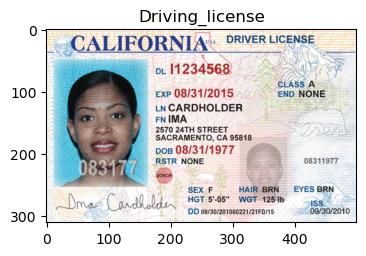

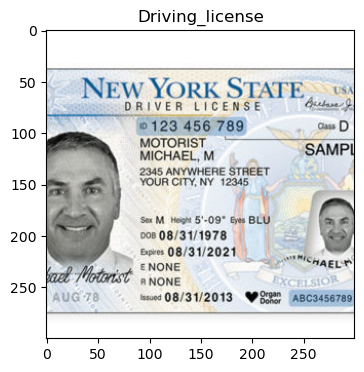

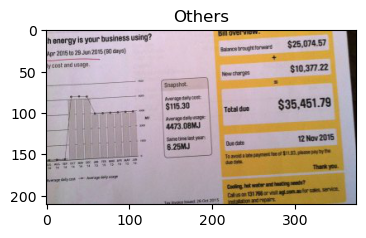

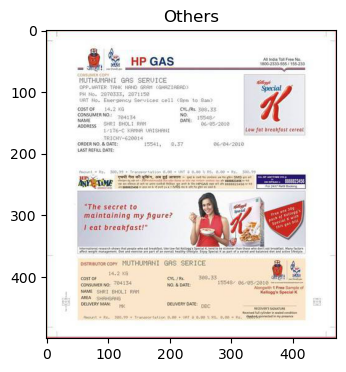

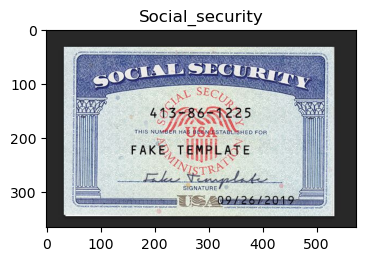

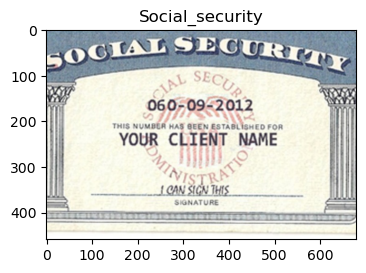

In [3]:
for path in os.listdir(Training_folder):
    for i in range(2):
        temp_path = os.path.join(Training_folder, path)
        file = random.choice(os.listdir(temp_path))
        image_path = os.path.join(temp_path, file)
        img = mpimg.imread(image_path)
        plt.figure(figsize=(4, 4))
        plt.title(path)
        plt.imshow(img)
        plt.show()

In [4]:
import cv2
import numpy as np
import os
from torchvision import transforms
from PIL import Image

IMG_WIDTH  = 200
IMG_HEIGHT = 200

#  Heavy augmentation for small dataset
augment = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
])

normal = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
])

def create_dataset(folder, augment_data=False, aug_per_image=4):
    img_data_array = []
    class_labels   = []

    classes = {
        'Driving_license': 0,
        'Others':          1,
        'Social_security': 2
    }

    for PATH in os.listdir(folder):
        if PATH not in classes:
            continue
        class_path = os.path.join(folder, PATH)
        for file in os.listdir(class_path):
            image_path = os.path.join(class_path, file)
            image = cv2.imread(image_path)
            if image is None:
                continue

            # Convert BGR to RGB
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.resize(image, (IMG_WIDTH, IMG_HEIGHT),
                               interpolation=cv2.INTER_AREA)

            #  Always add original image
            orig = image.astype('float32') / 255.0
            orig = orig.transpose(2, 0, 1)
            img_data_array.append(orig)
            class_labels.append(classes[PATH])

            #  Add augmented copies for training only
            if augment_data:
                for _ in range(aug_per_image):
                    aug_img = augment(image)   # returns tensor 0-1
                    img_data_array.append(aug_img.numpy())
                    class_labels.append(classes[PATH])

    return img_data_array, class_labels

print("Loading training data with augmentation...")
Train_img_data, train_class_name = create_dataset(
    Training_folder,
    augment_data=True,   #  augment training
    aug_per_image=4      #  4 extra copies per image = 5x dataset
)

print("Loading testing data without augmentation...")
Test_img_data, test_class_name = create_dataset(
    Test_folder,
    augment_data=False   #  never augment test data
)

print(f"\n Train images: {len(Train_img_data)}  "
      f"(was 600, now {len(Train_img_data)})")
print(f" Test  images: {len(Test_img_data)}")

Loading training data with augmentation...
Loading testing data without augmentation...

 Train images: 3000  (was 600, now 3000)
 Test  images: 150


In [5]:
import torch
import torch.utils.data as Data
from torch import Tensor

torch_dataset_train = Data.TensorDataset(
    Tensor(np.array(Train_img_data)),
    torch.LongTensor(train_class_name)
)
torch_dataset_test = Data.TensorDataset(
    Tensor(np.array(Test_img_data)),
    torch.LongTensor(test_class_name)
)

trainloader = Data.DataLoader(torch_dataset_train, batch_size=16, shuffle=True)
testloader  = Data.DataLoader(torch_dataset_test,  batch_size=16, shuffle=False)  #  False

print(f" Train samples: {len(torch_dataset_train)}")
print(f" Test samples:  {len(torch_dataset_test)}")
print(f" Train batches: {len(trainloader)}")
print(f" Test batches:  {len(testloader)}")

 Train samples: 3000
 Test samples:  150
 Train batches: 188
 Test batches:  10


In [6]:
import torch.nn as nn

class CNNNet(nn.Module):
    def __init__(self, num_classes=3):
        super(CNNNet, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),           #  stabilizes training
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),           #  stabilizes training
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),          #  stabilizes training
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

print(" Model defined successfully!")

 Model defined successfully!


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Using device: {device}")

model     = CNNNet(num_classes=3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0003)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    patience=3,
    factor=0.5
)

print(" Model, loss, optimizer ready!")

 Using device: cpu
 Model, loss, optimizer ready!


In [ ]:
num_epochs = 20
best_acc   = 0.0
patience   = 7
no_improve = 0

for epoch in range(num_epochs):

    # ── Train ──
    model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total   += labels.size(0)

    train_acc = 100 * correct / total

    # ── Validate ──
    model.eval()
    val_correct, val_total = 0, 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total   += labels.size(0)

    val_acc = 100 * val_correct / val_total

    scheduler.step(val_acc)  # ReduceLROnPlateau needs the metric

    print(f"Epoch {epoch+1:02d}/{num_epochs} | "
          f"Loss: {total_loss/len(trainloader):.4f} | "
          f"Train: {train_acc:.1f}% | "
          f"Val: {val_acc:.1f}%")

    # ── Save Best & Early Stop ──
    if val_acc > best_acc:
        best_acc   = val_acc
        no_improve = 0
        os.makedirs("output", exist_ok=True)
        torch.save(model.state_dict(), "output/model.pt")
        print(f"  model saved! Val Acc: {val_acc:.1f}%")
    else:
        no_improve += 1
        print(f"   No improvement {no_improve}/{patience}")
        if no_improve >= patience:
            print(f"\n Early stopping at epoch {epoch+1}")
            break

print(f"\n  Validation Accuracy: {best_acc:.1f}%")
print(f" model saved at: output/model.pt")

In [8]:
# loading the best save model 
model.load_state_dict(torch.load("output/model.pt", map_location=device))
model.to(device)
print("model loaded successfully from output/model.pt")

model loaded successfully from output/model.pt


In [9]:
## evaluating the model according my training code 

model.eval()
correct, total = 0, 0
class_correct = [0, 0, 0]
class_total   = [0, 0, 0]
class_names   = ["Driving_license", "Others", "Social_security"]

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total   += labels.size(0)
        for i in range(len(labels)):
            label = labels[i].item()
            class_correct[label] += (predicted[i] == labels[i]).item()
            class_total[label]   += 1

print(f"\n Overall Accuracy: {100 * correct / total:.2f}%\n")
for i in range(3):
    if class_total[i] > 0:
        print(f"  {class_names[i]}: "
              f"{100 * class_correct[i] / class_total[i]:.1f}% "
              f"({class_correct[i]}/{class_total[i]})")


 Overall Accuracy: 98.67%

  Driving_license: 100.0% (50/50)
  Others: 96.0% (48/50)
  Social_security: 100.0% (50/50)


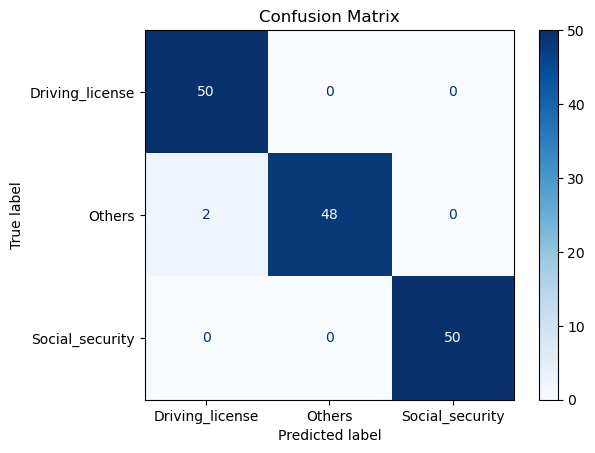

In [10]:
## confusion matrix 

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [11]:
# classification report 

from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds, target_names=class_names))

                 precision    recall  f1-score   support

Driving_license       0.96      1.00      0.98        50
         Others       1.00      0.96      0.98        50
Social_security       1.00      1.00      1.00        50

       accuracy                           0.99       150
      macro avg       0.99      0.99      0.99       150
   weighted avg       0.99      0.99      0.99       150



In [12]:
# checking exact image name from my folder 

import os

# This will show you all image names in each folder
for class_name in ["Driving_license", "Others", "Social_security"]:
    images = os.listdir(f"data/Testing_data/{class_name}")
    print(f"\n{class_name}:")
    for img in images[:3]:  # shows first 3 images
        print(f"  {img}")


Driving_license:
  1.jpg
  10.jpg
  11.jpg

Others:
  101.jpg
  102.jpg
  103.jpg

Social_security:
  100.jpg
  51.jpg
  52.jpg


In [13]:
# testing a single image 

from PIL import Image
from torchvision import transforms

# Define transform (same as your training transform)

transform = transforms.Compose([
    transforms.Resize((200, 200)),   # match training size
    transforms.ToTensor(),           # this already divides by 255
])

def predict_image(image_path):
    img = Image.open(image_path).convert("RGB")
    img = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(img)
        probabilities = torch.softmax(output, dim=1)[0]
        _, predicted = torch.max(output, 1)

    class_names = ["Driving_license", "Others", "Social_security"]
    print(f"Predicted Class : {class_names[predicted.item()]}")
    print(f"Confidence      : {probabilities[predicted.item()]*100:.2f}%")
    print("\nAll Probabilities:")
    for i, name in enumerate(class_names):
        print(f"  {name}: {probabilities[i]*100:.2f}%")

# Test all 3 classes
test_images = [
    (r"data\Testing_data\Driving_license\1.jpg",  "Driving_license"),
    (r"data\Testing_data\Others\101.jpg",          "Others"),
    (r"data\Testing_data\Social_security\51.jpg",  "Social_security"),
]

for image_path, true_label in test_images:
    print(f"\nTrue Label : {true_label}")
    predict_image(image_path)
    print("-" * 40)


True Label : Driving_license
Predicted Class : Driving_license
Confidence      : 99.90%

All Probabilities:
  Driving_license: 99.90%
  Others: 0.09%
  Social_security: 0.01%
----------------------------------------

True Label : Others
Predicted Class : Others
Confidence      : 95.00%

All Probabilities:
  Driving_license: 4.47%
  Others: 95.00%
  Social_security: 0.53%
----------------------------------------

True Label : Social_security
Predicted Class : Social_security
Confidence      : 99.88%

All Probabilities:
  Driving_license: 0.09%
  Others: 0.03%
  Social_security: 99.88%
----------------------------------------
